# Implementación Práctica: Agente Inteligente Autónomo para el Control de Glucosa

---

## 1. ¿Qué hace nuestro Agente Inteligente?
El agente desarrollado es un sistema de control biomédico autónomo que toma decisiones en tiempo real para mantener a un paciente diabético fuera de peligro. Su comportamiento se divide en dos fases perfectamente acopladas:

### A. Fase Teórica: El "Plano Mental" (Cálculo de la Tabla Q)
Antes de interactuar con el paciente, el agente ejecuta el algoritmo de **Iteración de Valor** para resolver el Proceso de Decisión de Markov (MDP). Utilizando la Ecuación de Consistencia de Bellman, el agente evalúa los **24 estados médicos posibles** y calcula de forma matemática exacta:
1. **La Función de Valor ($V^*$):** Identifica numéricamente qué tan seguro es cada estado a largo plazo (asignando máxima recompensa a la normoglucemia y penalizando severamente la hipoglucemia).
2. **La Política Óptima ($\pi^*$):** Construye una matriz de decisión fija de 24 reglas donde determina con precisión qué dosis de insulina (0u, 2u, 5u o 10u) es la ideal para cada combinación de glucosa, edad, peso y género, considerando los factores de resistencia biológica.

### B. Fase Práctica: El Control en Vivo (Simulación en Pygame)
Una vez entrenada la política, el agente toma el control de la simulación continua. Minuto a minuto, actúa de la siguiente manera:
* **Lectura del Estado:** Monitoriza los niveles continuos de glucosa del paciente y los traduce instantáneamente a un índice discreto.
* **Consulta Inmediata:** Va directamente a su matriz entrenada, busca la fila del estado actual y lee la dosis óptima asignada.
* **Inyección Automatizada:** Aplica la insulina (0u si está normal/bajo, o dosis más agresivas de hasta 10u si está alto) contrarrestando de forma inmediata los picos provocados por las ingestas de comida autónomas del entorno, estabilizando la curva de glucosa en el rango seguro (70 - 140 mg/dL).

### Importación de Librerías y Entorno de Desarrollo
En esta celda se cargan los módulos necesarios para el proyecto: `numpy` para el manejo de las matrices de transición y recompensa, `matplotlib` para los gráficos científicos y `pygame` para renderizar la interfaz médica en tiempo real.

In [109]:
import numpy as np
import matplotlib.pyplot as plt
import pygame
import sys

###  Definición del Entorno Biomédico (MDP)
Aquí se modela el cuerpo del paciente como un Proceso de Decisión de Markov Finito. Se definen las dimensiones del universo (24 estados y 4 acciones de insulina) y se construye la matriz estática de probabilidades de transición `p(s' | s, a)` y la matriz de recompensas, aplicando los factores de resistencia por edad, peso y género del examen.

In [110]:
class EntornoPacienteDP:
    def __init__(self):
        # 1. Definición de las dimensiones finitas del universo del paciente
        # Combinaciones: Glucosa (3) x Edad (2) x Peso (2) x Género (2) = 24 estados totales
        self.num_estados = 24  
        self.num_acciones = 4  # 0: No aplicar, 1: Dosis Baja, 2: Dosis Moderada, 3: Dosis Alta
        
        # 2. Matrices para Programación Dinámica (Método Tabular)
        # Matriz de transiciones p(s' | s, a) -> Tamaño: (24, 4, 24)
        self.probas_transiciones = np.zeros((self.num_estados, self.num_acciones, self.num_estados))
        
        # Matriz de recompensas esperadas r(s, a) -> Tamaño: (24, 4)
        self.recompensas = np.zeros((self.num_estados, self.num_acciones))
        
        # 3. Traductores para movernos entre índices numéricos e información médica
        self.nombre_glucosa = {0: "Hipoglucemia", 1: "Normoglucemia", 2: "Hiperglucemia"}
        self.nombre_edad = {0: "Joven", 1: "Adulto Mayor"}
        self.nombre_peso = {0: "Normal", 1: "Sobrepeso"}
        self.nombre_genero = {0: "Masculino", 1: "Femenino"}
        
        # Construcción del modelo al instanciar
        self._construir_modelo()

    def codificar_estado(self, glucosa, edad, peso, genero):
        """Convierte variables médicas discretas en un ID de estado único (0 a 23)."""
        return (glucosa * 8) + (edad * 4) + (peso * 2) + genero

    def decodificar_estado(self, estado_id):
        """Convierte un ID de estado (0 a 23) de regreso a sus componentes médicos."""
        glucosa = (estado_id // 8) % 3
        edad = (estado_id // 4) % 2
        peso = (estado_id // 2) % 2
        genero = estado_id % 2
        return glucosa, edad, peso, genero

    def _construir_modelo(self):
        """Construye las matrices de probabilidad de transición y recompensas."""
        for s in range(self.num_estados):
            glucosa, edad, peso, genero = self.decodificar_estado(s)
            
            # --- 1. ASIGNACIÓN DE RECOMPENSAS r(s, a) ---
            # Evaluamos la salud del estado actual (independiente de la acción)
            if glucosa == 1:    # Normoglucemia (¡Excelente!)
                recompensa_estado = 10.0
            elif glucosa == 0:  # Hipoglucemia (¡Peligro de muerte!)
                recompensa_estado = -20.0
            else:               # Hiperglucemia (Azúcar alta)
                recompensa_estado = -5.0
                
            for a in range(self.num_acciones):
                self.recompensas[s, a] = recompensa_estado
                
                # --- 2. FACTORES DE RESISTENCIA (Pregunta de Examen) ---
                # Modificamos la efectividad de la insulina según el paciente
                efectividad = 1.0
                if edad == 1:   # Adulto Mayor -> Menos sensible
                    efectividad -= 0.15
                if peso == 1:   # Sobrepeso -> Mayor resistencia periférica
                    efectividad -= 0.20
                if genero == 1: # Femenino -> Variación metabólica base
                    efectividad -= 0.05
                
                # --- 3. MODELADO DE TRANSICIONES p(s' | s, a) ---
                # Caso A: El paciente está en HIPERGLUCEMIA (Azúcar Alta)
                if glucosa == 2:
                    if a == 3:  # Dosis Alta
                        prob_bajar = 0.85 * efectividad
                        s_normal = self.codificar_estado(1, edad, peso, genero)
                        s_alto = self.codificar_estado(2, edad, peso, genero)
                        
                        self.probas_transiciones[s, a, s_normal] = prob_bajar
                        self.probas_transiciones[s, a, s_alto] = 1.0 - prob_bajar
                        
                    elif a == 2: # Dosis Moderada
                        prob_bajar = 0.50 * efectividad
                        s_normal = self.codificar_estado(1, edad, peso, genero)
                        s_alto = self.codificar_estado(2, edad, peso, genero)
                        
                        self.probas_transiciones[s, a, s_normal] = prob_bajar
                        self.probas_transiciones[s, a, s_alto] = 1.0 - prob_bajar
                        
                    else: # Dosis Baja o No Aplicar (Insuficiente)
                        s_alto = self.codificar_estado(2, edad, peso, genero)
                        self.probas_transiciones[s, a, s_alto] = 1.0

                # Caso B: El paciente está en NORMOGLUCEMIA (Azúcar Normal)
                elif glucosa == 1:
                    if a == 0:  # No aplicar (Acción correcta)
                        s_normal = self.codificar_estado(1, edad, peso, genero)
                        self.probas_transiciones[s, a, s_normal] = 1.0
                    elif a == 1: # Dosis Baja (Ligero exceso)
                        s_bajo = self.codificar_estado(0, edad, peso, genero)
                        s_normal = self.codificar_estado(1, edad, peso, genero)
                        self.probas_transiciones[s, a, s_bajo] = 0.30
                        self.probas_transiciones[s, a, s_normal] = 0.70
                    else: # Dosis Moderada o Alta (¡Exceso peligroso!)
                        s_bajo = self.codificar_estado(0, edad, peso, genero)
                        self.probas_transiciones[s, a, s_bajo] = 1.0

                # Caso C: El paciente está en HIPOGLUCEMIA (Azúcar Baja)
                else:
                    # Si ya está bajo, cualquier dosis de insulina lo mantiene abajo
                    s_bajo = self.codificar_estado(0, edad, peso, genero)
                    self.probas_transiciones[s, a, s_bajo] = 1.0



### Cerebro del Agente - Algoritmo de Programación Dinámica (Bellman)
Esta celda contiene la lógica del agente inteligente. Utiliza el algoritmo de **Iteración de Valor** para resolver las Ecuaciones de Consistencia de Bellman. El agente barre los estados calculando explícitamente la utilidad de cada dosis en la tabla `Q(s, a)` hasta que los valores convergen, extrayendo así la Política Óptima (`pi`) definitiva.

In [111]:
class AgentePacienteMDP:
    def __init__(self, entorno, gamma=0.95, theta=1e-6):
        self.env = entorno
        self.gamma = gamma  # Factor de descuento para recompensas futuras
        self.theta = theta  # Umbral de parada
        
        # --- ENFOQUE MDP COMPATIBLE CON NUESTRO CUADERNILLO BASE ---
        # En lugar de solo V(s), definimos la tabla Q(s, a) explícita de la materia
        # Tamaño: 24 estados x 4 acciones = 96 valores estado-acción
        self.Q = np.zeros((self.env.num_estados, self.env.num_acciones))
        
        # El vector V(s) se deriva directamente como el máximo de Q(s, a)
        self.V = np.zeros(self.env.num_estados)
        # Política óptima pi(s)
        self.pi = np.zeros(self.env.num_estados, dtype=int)

    def entrenar(self):
        """Resuelve el MDP usando la ecuación de consistencia de Bellman para Q(s,a)."""
        while True:
            delta = 0
            
            # Actualizamos los valores de V basándonos en la matriz Q actual
            for s in range(self.env.num_estados):
                self.V[s] = np.max(self.Q[s, :])
                
            # Hacemos el barrido por el espacio de estados y acciones para actualizar Q
            for s in range(self.env.num_estados):
                for a in range(self.env.num_acciones):
                    q_anterior = self.Q[s, a]
                    
                    # Ecuación de Bellman para q(s, a): suma sobre s' de p(s'|s,a) * [r(s,a) + gamma * V(s')]
                    valor_esperado = 0
                    for s_siguiente in range(self.env.num_estados):
                        prob = self.env.probas_transiciones[s, a, s_siguiente]
                        recompensa = self.env.recompensas[s, a]
                        
                        valor_esperado += prob * (recompensa + self.gamma * self.V[s_siguiente])
                    
                    # Guardamos el valor calculado en la tabla Q de MDP
                    self.Q[s, a] = valor_esperado
                    
                    # Medimos el cambio máximo para verificar la convergencia
                    delta = max(delta, abs(q_anterior - self.Q[s, a]))
            
            # Criterio de parada cuando los valores Q se estabilizan por completo
            if delta < self.theta:
                break
                
        # Una vez convergido, extraemos la política y dejamos el vector V final listo
        for s in range(self.env.num_estados):
            self.V[s] = np.max(self.Q[s, :])
            self.pi[s] = np.argmax(self.Q[s, :])
            
        print("¡Entrenamiento MDP finalizado! Tabla Q(s,a) calculada con éxito.")

###  Instanciación del Entorno y Entrenamiento Analítico
En este bloque se crea el objeto del paciente metabólico y se inicializa el agente bajo el marco MDP. Se ejecuta el método `.entrenar()` que calcula las 24 reglas óptimas de control de manera inmediata y exacta en la memoria del programa.

In [112]:
# Instanciamos el entorno y el nuevo agente bajo el marco de MDP
mi_entorno = EntornoPacienteDP()
mi_agente = AgentePacienteMDP(mi_entorno) # <- Usamos la versión MDP

# Entrenamos la tabla Q(s, a)
mi_agente.entrenar()

¡Entrenamiento MDP finalizado! Tabla Q(s,a) calculada con éxito.


###  Modelo Fisiológico Continuo para Simulación en Vivo
Aquí se programa la dinámica del cuerpo humano que correrá en tiempo real. A diferencia del entorno discreto del agente, esta clase maneja la glucosa y la insulina como valores decimales continuos (mg/dL) que disminuyen con el metabolismo y suben un +40 mg/dL de forma probabilística (2%) cuando el paciente digiere carbohidratos.

In [113]:
class SimulaciónPacienteTR:
    def __init__(self, edad=1, peso=1, genero=0):
        # Guardamos las características fijas del paciente elegido para la simulación
        self.edad = edad        # 0: Joven, 1: Adulto Mayor
        self.peso = peso        # 0: Normal, 1: Sobrepeso
        self.genero = genero    # 0: Masculino, 1: Femenino
        
        # Estado fisiológico inicial continuo (Glucosa real de inicio)
        self.glucosa_actual = 150.0  # mg/dL
        self.insulina_activa = 0.0   # Unidades en el cuerpo
        
        # ── ¡AQUÍ ESTÁ EL ARREGLO CLAVE! ─────────────────────────────────
        # Inicializamos la propiedad para que Pygame pueda leerla desde el segundo cero
        self.comio_este_minuto = False  
        
        # Historial para dibujar la curva en la pantalla de Pygame
        self.historial_glucosa = []

    def actualizar_un_minuto(self, accion_agente):
        """Simula el paso de 1 minuto en el cuerpo del paciente."""
        # Reiniciamos la bandera al iniciar el minuto
        self.comio_este_minuto = False  
        
        # 1. Procesar la acción tomada por el agente
        if accion_agente == 1:   # Dosis Baja
            self.insulina_activa += 2.0
        elif accion_agente == 2: # Dosis Moderada
            self.insulina_activa += 5.0
        elif accion_agente == 3: # Dosis Alta
            self.insulina_activa += 10.0
            
        # 2. Factor de resistencia (la misma lógica médica del examen)
        resistencia = 1.0
        if self.edad == 1: resistencia -= 0.15
        if self.peso == 1: resistencia -= 0.20
        
        # 3. Dinámica metabólica continua: la insulina baja la glucosa
        # ¡AQUÍ ESTÁ CORREGIDO! Línea limpia sin doble asignación:
        efecto_insulina = self.insulina_activa * 1.5 * resistencia
        self.glucosa_actual -= efecto_insulina
        
        # El cuerpo absorbe o elimina la insulina lentamente con el tiempo
        self.insulina_activa *= 0.8 
        
        # 4. Simulación de eventos: El paciente come aleatoriamente (2% de probabilidad por minuto)
        if np.random.rand() < 0.02:
            self.glucosa_actual += 40.0  # El carbohidrato sube la glucosa
            self.comio_este_minuto = True  # Activamos si come de forma aleatoria
        else:
            self.glucosa_actual += 0.5   # Subida natural por glucagón del hígado
            
        # Controlar límites lógicos del cuerpo humano
        self.glucosa_actual = max(20.0, min(self.glucosa_actual, 400.0))
        
        # Guardamos en el historial para la gráfica en vivo
        self.historial_glucosa.append(self.glucosa_actual)
        if len(self.historial_glucosa) > 300: 
            self.historial_glucosa.pop(0)
    def obtener_estado_discreto(self):
        """Traduce la glucosa continua a los ojos del Agente (0, 1 o 2)."""
        if self.glucosa_actual < 70:
            glucosa_disc = 0  # Hipoglucemia
        elif self.glucosa_actual <= 140:
            glucosa_disc = 1  # Normoglucemia
        else:
            glucosa_disc = 2  # Hiperglucemia
            
        return (glucosa_disc * 8) + (self.edad * 4) + (self.peso * 2) + self.genero

### Renderizado de la Interfaz Gráfica (Panel de Acciones)
Función auxiliar de Pygame encargada de dibujar de forma estética el panel derecho de la pantalla. Muestra las 4 dosis posibles e ilumina con un "LED virtual" y texto de alto contraste la acción exacta que el agente MDP está inyectando en ese minuto.

In [114]:
def dibujar_panel_acciones(pantalla, ultima_accion, fuente_texto, x, y):
    """
    Dibuja un panel con las 4 acciones posibles del agente.
    La acción activa se ilumina con su color correspondiente.
    Las inactivas se muestran en gris oscuro.
    """
    # Definición de cada acción: (etiqueta, color activo, color borde)
    acciones_info = [
        ("0u  Sin Insulina",   (50,  200,  80),  (120, 255, 140)),  # Verde brillante
        ("2u  Dosis Baja",     (30,  150, 255),  (100, 210, 255)),  # Azul eléctrico
        ("5u  Dosis Moderada", (255, 180,   0),  (255, 230,  80)),  # Amarillo/naranja
        ("10u Dosis Alta",     (230,  40,  60),  (255, 100, 120)),  # Rojo intenso
    ]

    GRIS_OSCURO = (70,  70,  80)
    GRIS_FONDO  = (40,  40,  55)
    BLANCO      = (255, 255, 255)

    ancho_btn = 175
    alto_btn  = 40
    margen    = 10
    radio     = 8

    # Título del panel con subrayado decorativo
    fuente_panel = pygame.font.SysFont("Arial", 14, bold=True)
    txt_panel = fuente_panel.render("⚡ ACCIONES DEL AGENTE", True, (180, 220, 255))
    pantalla.blit(txt_panel, (x, y - 26))
    pygame.draw.line(pantalla, (80, 130, 200), (x, y - 6), (x + ancho_btn, y - 6), 1)

    for i, (etiqueta, color_activo, color_borde_activo) in enumerate(acciones_info):
        rect_x = x
        rect_y = y + i * (alto_btn + margen)
        rect = pygame.Rect(rect_x, rect_y, ancho_btn, alto_btn)

        activo = (i == ultima_accion)

        if activo:
            # Sombra de resplandor detrás del botón activo
            sombra = pygame.Rect(rect_x - 3, rect_y - 3, ancho_btn + 6, alto_btn + 6)
            sombra_color = tuple(min(255, c // 2) for c in color_activo)
            pygame.draw.rect(pantalla, sombra_color, sombra, border_radius=radio + 2)

        # Fondo del botón
        color_fondo = color_activo if activo else GRIS_FONDO
        pygame.draw.rect(pantalla, color_fondo, rect, border_radius=radio)

        # Borde
        color_borde = color_borde_activo if activo else GRIS_OSCURO
        grosor_borde = 3 if activo else 1
        pygame.draw.rect(pantalla, color_borde, rect, grosor_borde, border_radius=radio)

        # LED indicador
        cx = rect_x + 16
        cy = rect_y + alto_btn // 2
        if activo:
            pygame.draw.circle(pantalla, tuple(min(255, c + 60) for c in color_activo), (cx, cy), 9)
            pygame.draw.circle(pantalla, (255, 255, 200), (cx, cy), 6)
        else:
            pygame.draw.circle(pantalla, (55, 55, 65), (cx, cy), 6)
        pygame.draw.circle(pantalla, (0, 0, 0), (cx, cy), 6, 1)

        # Texto de la acción
        color_txt = BLANCO if activo else (110, 110, 130)
        txt = fuente_texto.render(etiqueta, True, color_txt)
        pantalla.blit(txt, (rect_x + 32, rect_y + 12))

###  Motor Gráfico y Control Autónomo en Tiempo Real
Esta es la función principal de Pygame. Ejecuta el bucle de control continuo: monitoriza la glucosa del paciente, consulta la política entrenada, aplica la dosis y refresca la pantalla con la paleta de colores cibernética. Incluye la bitácora fija en el panel izquierdo para registrar de forma permanente en qué minuto ocurrió la ingesta de comida.

In [119]:
def simular_pygame_tr(agente, edad_sim, peso_sim, genero_sim, velocidad_fps=10):
    pygame.init()
    ANCHO, ALTO = 920, 540
    pantalla = pygame.display.set_mode((ANCHO, ALTO))
    pygame.display.set_caption("Simulador de Glucosa en Tiempo Real - Programación Dinámica")
    reloj = pygame.time.Clock()

    fuente_titulo = pygame.font.SysFont("Arial", 22, bold=True)
    fuente_texto  = pygame.font.SysFont("Arial", 16)

    paciente = SimulaciónPacienteTR(edad=edad_sim, peso=peso_sim, genero=genero_sim)

    # ── Paleta de colores (Tus colores intactos) ─────────────────────────
    FONDO_MAIN   = (15,  18,  35)
    FONDO_PANEL  = (22,  26,  50)
    FONDO_ACCION = (12,  14,  28)
    FONDO_GRAFICA= (25,  30,  55)
    BLANCO       = (230, 235, 255)
    GRIS_SUAVE   = (100, 110, 140)
    AMARILLO_VIV = (255, 220,  50)
    CIAN         = ( 50, 220, 220)
    AZUL_CURVA   = ( 80, 180, 255)
    VERDE_VIV    = ( 50, 230, 100)
    ROJO_VIV     = (255,  70,  70)
    NARANJA_VIV  = (255, 160,  30)
    MORADO       = (160,  80, 255)

    corriendo     = True
    minuto_actual = 0
    ultima_accion = 0
    
    # ── NUEVA VARIABLE DE BITÁCORA FIJA ──────────────────────────────────
    # Guardará el texto del último evento clínico para que no desaparezca rápido
    registro_ultimo_evento = "Ayuno Basal (Estable)"
    hubo_comida_reciente = False

    print("Iniciando ventana de Pygame... Cierra la ventana gráfica para terminar.")
    print("-> Modo Autónomo Activado: El paciente comerá solo y dejará registro clínico. <-")

    while corriendo:
        for evento in pygame.event.get():
            if evento.type == pygame.QUIT:
                corriendo = False

        # --- LÓGICA DE CONTROL ---
        estado_id     = paciente.obtener_estado_discreto()
        ultima_accion = agente.pi[estado_id]
        
        # El metabolismo avanza de forma 100% automática minuto a minuto
        paciente.actualizar_un_minuto(ultima_accion)
        minuto_actual += 1
        
        # ── NUEVA LÓGICA DE ACTUALIZACIÓN DE BITÁCORA ─────────────────────
        # Si el cuerpo del paciente decide comer por azar en este minuto...
        if paciente.comio_este_minuto:
            # Grabamos fijamente el mensaje con el minuto exacto del evento
            registro_ultimo_evento = f"Ingesta de Carbohidratos (Min {minuto_actual})"
            hubo_comida_reciente = True
            paciente.comio_este_minuto = False # Limpiamos la bandera inmediatamente
        
        # Si la glucosa vuelve a la normalidad, podemos actualizar el indicador sutilmente
        if hubo_comida_reciente and paciente.glucosa_actual <= 140 and paciente.glucosa_actual >= 70:
            # Solo si quieres que cambie al estabilizarse, si no, puedes dejarlo fijo
            hubo_comida_reciente = False

        # ── FONDOS ───────────────────────────────────────────────────────
        pantalla.fill(FONDO_MAIN)
        pygame.draw.rect(pantalla, FONDO_PANEL,  (0,   0, 220, ALTO))
        pygame.draw.rect(pantalla, MORADO,       (218, 0,   2, ALTO))
        pygame.draw.rect(pantalla, FONDO_ACCION, (700, 0, 220, ALTO))
        pygame.draw.rect(pantalla, CIAN,         (700, 0,   2, ALTO))

        # ── TÍTULO ───────────────────────────────────────────────────────
        txt_titulo = fuente_titulo.render("Monitoreo Fisiológico del Paciente", True, AMARILLO_VIV)
        pantalla.blit(txt_titulo, (225, 12))
        pygame.draw.line(pantalla, MORADO, (225, 38), (695, 38), 1)

        # ── COLOR DE ALERTA ───────────────────────────────────────────────
        g_id = (estado_id // 8) % 3
        if g_id == 1:   color_alerta = VERDE_VIV
        elif g_id == 2: color_alerta = NARANJA_VIV
        else:           color_alerta = ROJO_VIV

        nombres_estado = {1: "NORMAL", 2: "ALTA ▲", 0: "BAJA ▼"}
        badge_txt = pygame.font.SysFont("Arial", 15, bold=True).render(
            f"● {nombres_estado[g_id]}", True, color_alerta)
        pantalla.blit(badge_txt, (15, 14))

        # ── PANEL DE DATOS MÉDICOS ────────────────────────────────────────
        medicos_info = [
            ("Tiempo",          f"{minuto_actual} min",              CIAN),
            ("Edad",            mi_entorno.nombre_edad[edad_sim],    BLANCO),
            ("Peso",            mi_entorno.nombre_peso[peso_sim],    BLANCO),
            ("Genero",          mi_entorno.nombre_genero[genero_sim],BLANCO),
            ("Glucosa",         f"{paciente.glucosa_actual:.1f} mg/dL", color_alerta),
            ("Insulina activa", f"{paciente.insulina_activa:.2f} u", AMARILLO_VIV),
        ]

        y_offset = 55
        for etiqueta, valor, color_val in medicos_info:
            lbl = fuente_texto.render(etiqueta + ":", True, GRIS_SUAVE)
            val = fuente_texto.render(valor,          True, color_val)
            pantalla.blit(lbl, (12, y_offset))
            pantalla.blit(val, (12, y_offset + 18))
            y_offset += 48

        # ── PANEL IZQUIERDO: REGISTRO CLÍNICO FIJO DE EVENTOS ────────────
        lbl_estado = fuente_texto.render("Historial de Alerta:", True, GRIS_SUAVE)
        pantalla.blit(lbl_estado, (12, y_offset))
        
        # El texto se renderiza dinámicamente según el contenido de nuestra bitácora fija
        if "Ingesta" in registro_ultimo_evento:
            color_registro = NARANJA_VIV
            # Contenedor estético oscuro con borde naranja
            pygame.draw.rect(pantalla, (45, 25, 15), (10, y_offset + 18, 200, 34), border_radius=4)
            pygame.draw.rect(pantalla, NARANJA_VIV, (10, y_offset + 18, 200, 34), 1, border_radius=4)
        else:
            color_registro = BLANCO
            pygame.draw.rect(pantalla, (28, 32, 58), (10, y_offset + 18, 200, 34), border_radius=4)
            pygame.draw.rect(pantalla, GRIS_SUAVE, (10, y_offset + 18, 200, 34), 1, border_radius=4)
            
        txt_bitacora = pygame.font.SysFont("Arial", 11, bold=True).render(registro_ultimo_evento, True, color_registro)
        pantalla.blit(txt_bitacora, (16, y_offset + 28))

        # ── PANEL DE ACCIONES ─────────────────────────────────────────────
        dibujar_panel_acciones(pantalla, ultima_accion, fuente_texto, x=712, y=90)

        # ── ZONA DE GRÁFICA ───────────────────────────────────────────────
        origen_x      = 225
        origen_y      = ALTO - 18
        grafica_ancho = 465
        grafica_alto  = 280

        pygame.draw.rect(pantalla, FONDO_GRAFICA,
                         (origen_x, origen_y - grafica_alto, grafica_ancho, grafica_alto),
                         border_radius=6)
        pygame.draw.rect(pantalla, GRIS_SUAVE,
                         (origen_x, origen_y - grafica_alto, grafica_ancho, grafica_alto),
                         1, border_radius=6)

        # Líneas de referencia médicas
        y_70  = origen_y - int((70  / 400.0) * grafica_alto)
        y_140 = origen_y - int((140 / 400.0) * grafica_alto)
        pygame.draw.line(pantalla, ROJO_VIV,    (origen_x, y_70),  (origen_x + grafica_ancho, y_70),  1)
        pygame.draw.line(pantalla, (80,100,80), (origen_x, y_140), (origen_x + grafica_ancho, y_140), 1)
        pantalla.blit(fuente_texto.render("70",  True, ROJO_VIV),     (origen_x + grafica_ancho + 4, y_70  - 8))
        pantalla.blit(fuente_texto.render("140", True, (80, 160, 80)),(origen_x + grafica_ancho + 4, y_140 - 8))

        # Curva de glucosa continua
        historial = paciente.historial_glucosa
        if len(historial) > 1:
            puntos_linea = []
            for i, val in enumerate(historial):
                x_pixel = origen_x + int((i / 300.0) * grafica_ancho)
                y_pixel = origen_y  - int((val / 400.0) * grafica_alto)
                puntos_linea.append((x_pixel, y_pixel))
            pygame.draw.lines(pantalla, AZUL_CURVA, False, puntos_linea, 3)

        pygame.display.flip()
        reloj.tick(velocidad_fps)

    pygame.quit()
    print("Simulación en tiempo real finalizada con éxito.")

### Lanzamiento de la Simulación Médica Personalizada
Celda de ejecución final. Aquí se configuran las características específicas del paciente a evaluar (ej. Adulto Mayor, Con Sobrepeso, Masculino) y se arranca la simulación interactiva a 15 cuadros por segundo para auditar el desempeño del agente en vivo.

In [121]:
# CONFIGURA AQUÍ TU PACIENTE PARA LA DEFENSA:
# Edad ->   0: Joven,     1: Adulto Mayor
# Peso ->   0: Normal,    1: Sobrepeso
# Género -> 0: Masculino, 1: Femenino

simular_pygame_tr(
    agente=mi_agente, 
    edad_sim=1,     # Adulto Mayor
    peso_sim=1,     # Con Sobrepeso (mayor resistencia a la insulina)
    genero_sim=0,   # Masculino
    velocidad_fps=15 # Cuadros por segundo (Súbelo si quieres que el tiempo pase más rápido)
)

Iniciando ventana de Pygame... Cierra la ventana gráfica para terminar.
-> Modo Autónomo Activado: El paciente comerá solo y dejará registro clínico. <-
Simulación en tiempo real finalizada con éxito.


### Visualización Científica - Mapa de Calor Teórico
Bloque final que genera el gráfico solicitado por la materia. Toma la matriz `Q(s, a)` calculada por el agente y la dibuja como una cuadrícula de colores (de rojo a verde) anotando el valor numérico neto y la dosis recomendada para demostrar analíticamente cómo se resolvió el MDP.

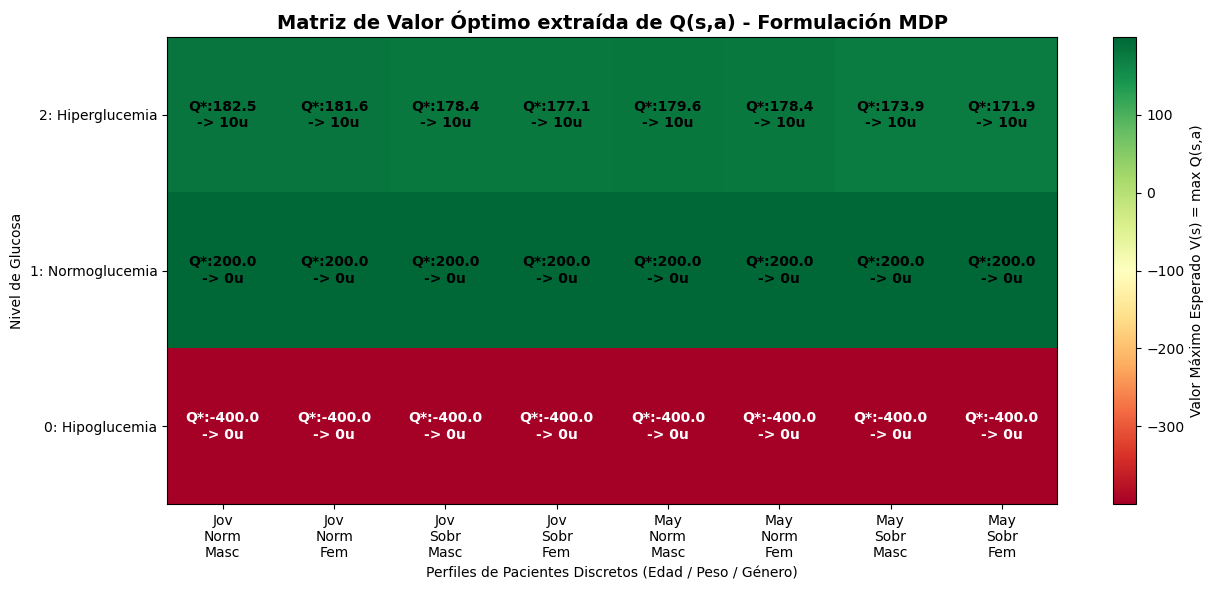

In [117]:
def graficar_politica_mdp(agente):
    """Genera el mapa de calor basado en la estructura de valor Q(s,a) de MDP."""
    # Creamos matrices vacías para mapear las dimensiones a la cuadrícula (3 filas de glucosa x 8 perfiles)
    matriz_V = np.zeros((3, 8))
    matriz_pi = np.zeros((3, 8), dtype=int)
    etiquetas_X = []
    
    # Reorganizamos los 24 estados para la visualización gráfica
    for g in range(3):
        col = 0
        for ed in range(2):
            for p in range(2):
                for gen in range(2):
                    s = agente.env.codificar_estado(g, ed, p, gen)
                    
                    # --- CONEXIÓN MDP ---
                    # El valor del estado V(s) es el máximo de sus acciones en Q(s,a)
                    matriz_V[g, col] = np.max(agente.Q[s, :])
                    # La política pi(s) es la acción que tiene el valor Q más alto
                    matriz_pi[g, col] = np.argmax(agente.Q[s, :])
                    
                    if g == 0:
                        nom_ed = "May" if ed==1 else "Jov"
                        nom_p = "Sobr" if p==1 else "Norm"
                        nom_g = "Fem" if gen==1 else "Masc"
                        etiquetas_X.append(f"{nom_ed}\n{nom_p}\n{nom_g}")
                    col += 1

    # Diseño del gráfico con Matplotlib
    plt.figure(figsize=(13, 6))
    
    # Dibujamos el mapa con la paleta de Rojo (Peligro) a Verde (Seguro)
    im = plt.imshow(matriz_V, cmap='RdYlGn', aspect='auto', origin='lower')
    plt.colorbar(im, label="Valor Máximo Esperado V(s) = max Q(s,a)")
    
    plt.yticks([0, 1, 2], ['0: Hipoglucemia', '1: Normoglucemia', '2: Hiperglucemia'])
    plt.xticks(range(8), etiquetas_X)
    plt.ylabel("Nivel de Glucosa")
    plt.xlabel("Perfiles de Pacientes Discretos (Edad / Peso / Género)")
    plt.title("Matriz de Valor Óptimo extraída de Q(s,a) - Formulación MDP", fontsize=14, fontweight='bold')
    
    acciones_texto = {0: "0u", 1: "2u", 2: "5u", 3: "10u"}
    
    # Anotamos los datos matemáticos dentro de cada celda
    for g in range(3):
        for col in range(8):
            val_optimo = matriz_V[g, col]
            accion_optima = matriz_pi[g, col]
            
            # Formateamos el texto para mostrar que la decisión viene de la matriz Q
            texto_celda = f"Q*:{val_optimo:.1f}\n-> {acciones_texto[accion_optima]}"
            
            color_texto = 'white' if val_optimo < -10 else 'black'
            plt.text(col, g, texto_celda, ha="center", va="center", color=color_texto, fontweight='bold')
            
    plt.tight_layout()
    plt.show()

# Ejecutar visualización final
graficar_politica_mdp(mi_agente)